In [1]:
from langgraph.graph import StateGraph, START, END

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal, List
from pydantic import BaseModel, Field

In [2]:
load_dotenv()

True

In [3]:
docs = (
    PyPDFLoader(r"C:\Users\Administrator\Desktop\LangGraph Exploration\Day26_Self_RAG\documents\Company_Policies.pdf").load() +
    PyPDFLoader(r"C:\Users\Administrator\Desktop\LangGraph Exploration\Day26_Self_RAG\documents\Company_Profile.pdf").load() +
    PyPDFLoader(r"C:\Users\Administrator\Desktop\LangGraph Exploration\Day26_Self_RAG\documents\Product_and_Pricing.pdf").load()
)

In [4]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 600, chunk_overlap = 150)
chunks = splitter.split_documents(docs)

In [5]:
embeddings = OpenAIEmbeddings(model = "text-embedding-3-small")
vector_store = FAISS.from_documents(chunks, embedding = embeddings)

In [6]:
retriever = vector_store.as_retriever(search_type = "similarity", search_kwargs = {"k": 4})

In [7]:
llm = ChatOpenAI(model = "gpt-4o-mini", temperature = 0)

In [9]:
class State(TypedDict):
    question: str

    # new
    retrieval_query: str  # this query will be sent to the retriever everytime. So, initially question will be same as retrieval_query
    rewrite_tries: int

    # same as before
    needs_retrieval: bool
    docs: List[Document]
    relevant_docs: List[Document]
    context: str
    answer: str

    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: List[str]

    retries: int

    isuse: Literal['useful', 'not_useful']
    use_reason: str

In [10]:
# same as before

class RetrievedDecision(BaseModel):
    should_retrieve: Annotated[bool, Field(description = "True if external documents are needed to answer reliably, else False.")]

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}")
    ]
)

should_retrieve_chain = decide_retrieval_prompt | llm.with_structured_output(RetrievedDecision)

def decide_retrieval(state: State):
    question = state['question']
    decision: RetrievedDecision = should_retrieve_chain.invoke({"question": question})
    return {"needs_retrieval": decision.should_retrieve}

In [11]:
# same as before

direct_generate_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}")
    ]
)

def generate_direct(state: State):
    out = llm.invoke(direct_generate_prompt.format_messages(question = state['question']))
    return {"answer": out.content}

In [23]:
# modified -> replaced 'question' with 'retrieval_query'

def retrieve(state: State):
    docs = retriever.invoke(state['retrieval_query'])
    return {"docs": docs}

In [13]:
# same as before

def route_after_decide(state: State):
    if state['needs_retrieval']:
        return "retrieve"
    else:
        return "generate_direct"

In [14]:
# same as before

class RelevanceDecision(BaseModel):
    is_relevant: Annotated[bool, Field(description = "True if the document helps answer the question, else False.")]

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

fetch_relevant_chain = is_relevant_prompt | llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    relevant_docs: List[Document] = []

    for doc in state['docs']:
        decision: RelevanceDecision = fetch_relevant_chain.invoke({"question": state['question'], "document": doc.page_content})
        if decision.is_relevant:
            relevant_docs.append(doc)
    
    return {"relevant_docs": relevant_docs}

In [15]:
# same as before

rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state: State):
    context = "\n\n---\n\n".join(doc.page_content for doc in state.get("relevant_docs", [])).strip()
    if not context:
        return {"answer": "No relevant documents found", "context": ""}
    
    out = llm.invoke(rag_generation_prompt.format_messages(question = state['question'], context = context))
    return {"answer": out.content, "context": context}

In [16]:
# same as before

def no_relevant_docs(state: State):
    return {"answer": "No relevant documents found", "context": ""}

In [17]:
# same as before

def route_after_relevance(state: State):
    if state.get("relevant_docs") and len(state['relevant_docs']) > 0:
        return "generate_from_context"
    else:
        return "no_relevant_docs"

In [18]:
# same as before

class IsSUPDecision(BaseModel):
    issup: Literal["fully_supported", "partially_supported", "no_support"]
    evidence: Annotated[
        List[str], 
        Field(
            default_factory = list, 
            description = "include up to 3 short direct quotes from CONTEXT that support the supported parts."
            )
        ]    # Again, this is just for debugging purpose. You can exclude it if you want.


issup_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are verifying whether the ANSWER is supported by the CONTEXT.\n"
            "Return JSON with keys: issup, evidence.\n"
            "issup must be one of: fully_supported, partially_supported, no_support.\n\n"
            "How to decide issup:\n"
            "- fully_supported:\n"
            "  Every meaningful claim is explicitly supported by CONTEXT, and the ANSWER does NOT introduce\n"
            "  any qualitative/interpretive words that are not present in CONTEXT.\n"
            "  (Examples of disallowed words unless present in CONTEXT: culture, generous, robust, designed to,\n"
            "  supports professional development, best-in-class, employee-first, etc.)\n\n"
            "- partially_supported:\n"
            "  The core facts are supported, BUT the ANSWER includes ANY abstraction, interpretation, or qualitative\n"
            "  phrasing not explicitly stated in CONTEXT (e.g., calling policies 'culture', saying leave is 'generous',\n"
            "  or inferring outcomes like 'supports professional development').\n\n"
            "- no_support:\n"
            "  The key claims are not supported by CONTEXT.\n\n"
            "Rules:\n"
            "- Be strict: if you see ANY unsupported qualitative/interpretive phrasing, choose partially_supported.\n"
            "- If the answer is mostly unrelated to the question or unsupported, choose no_support.\n"
            "- Evidence: include up to 3 short direct quotes from CONTEXT that support the supported parts.\n"
            "- Do not use outside knowledge."
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Answer:\n{answer}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

issup_chain = issup_prompt | llm.with_structured_output(IsSUPDecision)

def is_sup(state: State):
    decision: IsSUPDecision = issup_chain.invoke({
        "question": state['question'],
        "answer": state['answer'],
        "context": state['context']
    })

    return {"issup": decision.issup, "evidence": decision.evidence}

In [19]:
# same as before

revise_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a STRICT reviser.\n\n"
            "You must output based on the following format:\n\n"
            "FORMAT (quote-only answer):\n"
            "- <direct quote from the CONTEXT>\n"
            "- <direct quote from the CONTEXT>\n\n"
            "Rules:\n"
            "- Use ONLY the CONTEXT.\n"
            "- Do NOT add any new words besides bullet dashes and the quotes themselves.\n"
            "- Do NOT explain anything.\n"
            "- Do NOT say 'context', 'not mentioned', 'does not mention', 'not provided', etc.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Current Answer:\n{answer}\n\n"
            "CONTEXT:\n{context}"
        ),
    ]
)

def revise_answer(state: State):
    out = llm.invoke(
        revise_prompt.format_messages(
            question = state['question'],
            answer = state['answer'],
            context = state['context']
        )
    )

    retries = state.get("retries", 0)
    retries += 1

    return {"answer": out.content, "retries": retries}

In [20]:
# same as before

MAX_RETRIES = 10

def route_after_issup(state: State):
    if state.get("issup") == "fully_supported":
        return "accept_answer"
    if state.get("retries", 0) >= MAX_RETRIES:
        return "accept_answer"   # or return a "give_up" node if you want
    return "revise_answer"

In [26]:
# same as before

class IsUSEDecision(BaseModel):
    isuse: Literal["useful", "not_useful"]
    reason: Annotated[str, Field(description = "Short reason in 1 line.")]

isuse_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging USEFULNESS of the ANSWER for the QUESTION.\n\n"
            "Goal:\n"
            "- Decide if the answer actually addresses what the user asked.\n\n"
            "Return JSON with keys: isuse, reason.\n"
            "isuse must be one of: useful, not_useful.\n\n"
            "Rules:\n"
            "- useful: The answer directly answers the question or provides the requested specific info.\n"
            "- not_useful: The answer is generic, off-topic, or only gives related background without answering.\n"
            "- Do NOT use outside knowledge.\n"
            "- Do NOT re-check grounding (IsSUP already did that). Only check: 'Did we answer the question?'\n"
            "- Keep reason to 1 short line."
        ),
        ("human", "Question:\n{question}\n\nAnswer:\n{answer}")
    ]
)

isuse_chain = isuse_prompt | llm.with_structured_output(IsUSEDecision)

def is_use(state: State):
    decision: IsUSEDecision = isuse_chain.invoke({"question": state["question"], "answer": state["answer"]})
    return {"isuse": decision.isuse, "use_reason": decision.reason}

In [25]:
# new

class RewriteDecision(BaseModel):
    retrieval_query: Annotated[str, Field(description = "Rewritten query optimized for vector retrieval against internal company PDFs.")]

rewrite_for_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user's QUESTION into a query optimized for vector retrieval over INTERNAL company PDFs.\n\n"
            "Rules:\n"
            "- Keep it short (6-16 words).\n"
            "- Preserve key entities (e.g., NexaAI, plan names).\n"
            "- Add 2-5 high-signal keywords that likely appear in policy/pricing docs.\n"
            "- Remove filler words.\n"
            "- Do NOT answer the question.\n"
            "- Output JSON with key: retrieval_query\n\n"
            "Examples:\n"
            "Q: 'Do NexaAI plans include a free trial?'\n"
            "-> {{'retrieval_query': 'NexaAI free trial duration trial period plans'}}\n\n"
            "Q: 'What is NexaAI refund policy?'\n"
            "-> {{'retrieval_query': 'NexaAI refund policy cancellation refund timeline charges'}}"
        ),
        (
            "human",
            "QUESTION:\n{question}\n\n"
            "Previous retrieval query:\n{retrieval_query}\n\n"
            "Answer (if any):\n{answer}"
        ),
    ]
)

rewrite_chain = rewrite_for_retrieval_prompt | llm.with_structured_output(RewriteDecision)

def rewrite_question(state: State):
    decision: RewriteDecision = rewrite_chain.invoke({
        "question": state['question'],
        "retrieval_query": state['retrieval_query'],
        "answer": state.get("answer", "")
    })

    rewrite_tries = state.get("rewrite_tries", 0) + 1
    return {
        "retrieval_query": decision.retrieval_query,
        "rewrite_tries": rewrite_tries,
        # optional: reset these so next pass is clean
        "docs": [],
        "relevant_docs": [],
        "context": ""
    }

In [27]:
# modified

MAX_REWRITE_TRIES = 3 # tune (2-4 is usualy fine)
def route_after_isuse(state: State):
    if state.get("isuse") == "useful":
        return "Yes"
    elif state.get("rewrite_tries", 0) >= MAX_REWRITE_TRIES:
        return "No"
    else:
        return "Retry"

In [28]:
graph = StateGraph(State)

graph.add_node("decide_retrieval", decide_retrieval)
graph.add_node("generate_direct", generate_direct)
graph.add_node("retrieve", retrieve)
graph.add_node("is_relevant", is_relevant)
graph.add_node("generate_from_context", generate_from_context)
graph.add_node("no_relevant_docs", no_relevant_docs)
graph.add_node("is_sup", is_sup)
graph.add_node("revise_answer", revise_answer)
graph.add_node("is_use", is_use)
graph.add_node("rewrite_question", rewrite_question)  # new

graph.add_edge(START, "decide_retrieval")
graph.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "retrieve": "retrieve",
        "generate_direct": "generate_direct"
    }
)
graph.add_edge("generate_direct", END)
graph.add_edge("retrieve", "is_relevant")

graph.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "no_relevant_docs": "no_relevant_docs"
    }
)

graph.add_edge("no_relevant_docs", END)
graph.add_edge("generate_from_context", "is_sup")


graph.add_conditional_edges(
    "is_sup",
    route_after_issup,
    {
        "accept_answer": "is_use",
        "revise_answer": "revise_answer"
    }
)

graph.add_edge("revise_answer", "is_sup")

# modified conditional edge
graph.add_conditional_edges(
    "is_use",
    route_after_isuse,
    {
        "Yes": END,
        "No": "no_relevant_docs",
        "Retry": "rewrite_question"
    }
)
graph.add_edge("rewrite_question", "retrieve")


workflow = graph.compile()

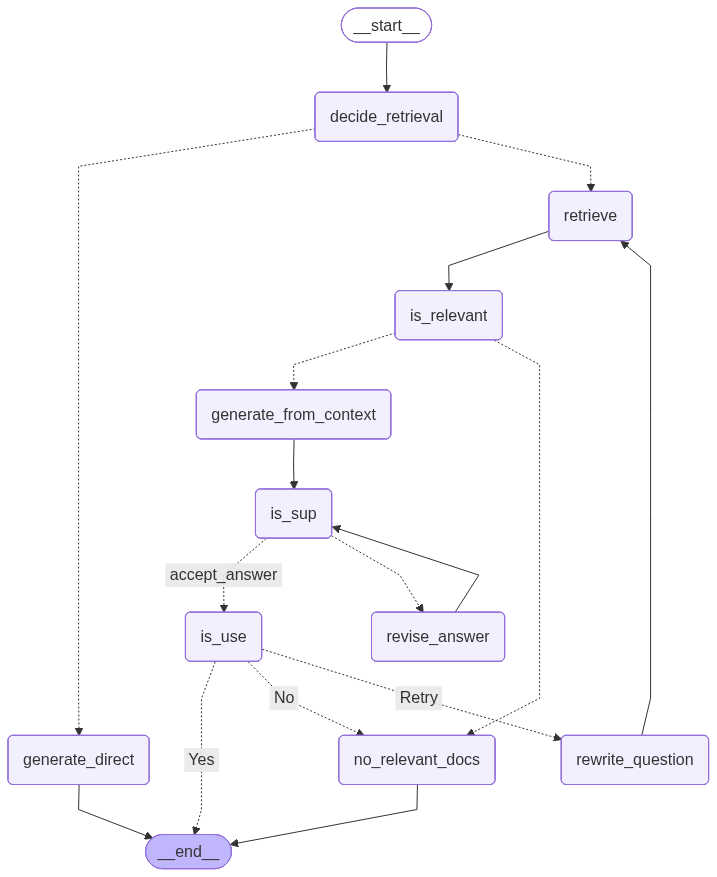

In [29]:
workflow

In [34]:
initial_state = {
    "question": "Describe NexaAI's company culture.",
    "retrieval_query": "What is the refund policy of NexaAI",  # important -> initially, retrieval_query = question
    "rewrite_tries": 0,                                        # important
    "docs": [],
    "relevant_docs": [],
    "context": "",
    "answer": "",
    "issup": "",
    "evidence": [],
    "retries": 0,
    "isuse": "not_useful",
    "use_reason": "",
}


result = workflow.invoke(
    initial_state,
    config={"recursion_limit": 80}
)

In [35]:
print("\n===== RAG EXECUTION RESULT =====\n")

print("Question:", initial_state.get("question"))
print("Needs Retrieval:", result.get("needs_retrieval"))

# If you added these counters/fields in your State:
print("Rewrite tries (retrieval):", result.get("rewrite_tries", 0))
print("Support revise tries:", result.get("retries", 0))

print("\nRetrieval:")
print("  Total retrieved docs:", len(result.get("docs", []) or []))
print("  Relevant docs:", len(result.get("relevant_docs", []) or []))

# Optional: show sources/pages for relevant docs
relevant_docs = result.get("relevant_docs", []) or []
if relevant_docs:
    print("\nRelevant docs (source/page):")
    for i, d in enumerate(relevant_docs, 1):
        src = (d.metadata or {}).get("source", "unknown")
        page = (d.metadata or {}).get("page", None)
        title = (d.metadata or {}).get("title", "")
        extra = f", title={title}" if title else ""
        if page is not None:
            print(f"  {i}. source={src}, page={page}{extra}")
        else:
            print(f"  {i}. source={src}{extra}")

print("\nVerification (IsSUP):")
print("  issup:", result.get("issup"))
evidence = result.get("evidence", []) or []
if evidence:
    print("  evidence:")
    for e in evidence:
        print("   -", e)
else:
    print("  evidence: (none)")

print("\nUsefulness (IsUSE):")
print("  isuse:", result.get("isuse"))
print("  reason:", result.get("use_reason", ""))

print("\nFinal Answer:")
print(result.get("answer"))

print("\n===============================\n")


===== RAG EXECUTION RESULT =====

Question: Describe NexaAI's company culture.
Needs Retrieval: True
Rewrite tries (retrieval): 0
Support revise tries: 1

Retrieval:
  Total retrieved docs: 4
  Relevant docs: 1

Relevant docs (source/page):
  1. source=C:\Users\Administrator\Desktop\LangGraph Exploration\Day26_Self_RAG\documents\Company_Policies.pdf, page=0, title=(anonymous)

Verification (IsSUP):
  issup: fully_supported
  evidence:
   - NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace.
   - Employees are encouraged to maintain a healthy work-life balance.

Usefulness (IsUSE):
  isuse: useful
  reason: The answer provides specific details about NexaAI's company culture.

Final Answer:
- "NexaAI is committed to maintaining a fair, inclusive, and performance-driven workplace."
- "Employees are encouraged to maintain a healthy work-life balance."


